**Lab #3-**

Your Name

**Find a complete social network, preferably one with at least some attributes about the nodes with it.**

This network is the Lazega friendship network and it represents who seeks out whom as a friend within a law firm, rather than purely professional relationships.  I am pulling it directly from this great site of networks (no longer active, but available through WayBack Machine!).

In [1]:
import pandas as pd
import requests

# Define the URL
url = "https://web.archive.org/web/20200706021849/http://moreno.ss.uci.edu/lazega.dat"

# Fetch the data
response = requests.get(url)
data = response.text

# Extract the adjacency matrix
# Split the file into lines
lines = data.splitlines()

# Find the index where the data starts
data_start_index = lines.index("DATA:") + 1  # The data starts right after "DATA:"

# Adjust starting position to skip 71 lines after "DATA:"
adjusted_start = data_start_index + 71

# Read only the next 71 lines from the adjusted start
matrix_lines = lines[adjusted_start:adjusted_start + 71]

# Convert the extracted lines into a DataFrame
matrix_data = [list(map(int, line.split())) for line in matrix_lines]
df = pd.DataFrame(matrix_data)

# Print the DataFrame
print(df)

    0   1   2   3   4   5   6   7   8   9   ...  61  62  63  64  65  66  67  \
0    0   1   0   1   0   0   0   1   0   0  ...   0   0   0   0   0   0   0   
1    0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
2    0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
3    0   1   1   0   0   0   0   0   1   0  ...   0   0   0   0   0   0   0   
4    0   0   0   0   0   0   1   0   0   0  ...   0   0   0   0   0   0   0   
..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..  ..  ..   
66   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   1   
67   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   1   0   0   0   
68   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   1   1   1   
69   0   0   0   0   0   0   0   0   0   0  ...   0   0   1   0   1   1   1   
70   0   0   0   0   0   0   0   0   0   0  ...   0   0   1   0   0   0   0   

    68  69  70  
0    0   0   0  
1    0   0   0  


In [2]:
# Ensure row and column names are 1-71 instead of 0-70
df.index = range(1, 72)  # Change row index to 1-71
df.columns = range(1, 72)  # Change column labels to 1-71

# Display the corrected DataFrame
print(df)


    1   2   3   4   5   6   7   8   9   10  ...  62  63  64  65  66  67  68  \
1    0   1   0   1   0   0   0   1   0   0  ...   0   0   0   0   0   0   0   
2    0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
3    0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   0   
4    0   1   1   0   0   0   0   0   1   0  ...   0   0   0   0   0   0   0   
5    0   0   0   0   0   0   1   0   0   0  ...   0   0   0   0   0   0   0   
..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ...  ..  ..  ..  ..  ..  ..  ..   
67   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   0   0   1   
68   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   1   0   0   0   
69   0   0   0   0   0   0   0   0   0   0  ...   0   0   0   0   1   1   1   
70   0   0   0   0   0   0   0   0   0   0  ...   0   0   1   0   1   1   1   
71   0   0   0   0   0   0   0   0   0   0  ...   0   0   1   0   0   0   0   

    69  70  71  
1    0   0   0  
2    0   0   0  


Now, I am collecting the attribute data for each lawyer...

In [3]:
import pandas as pd
import requests

# Define the URL
url = "https://web.archive.org/web/20200706021844/http://moreno.ss.uci.edu/lazatt.dat"

# Fetch the data
response = requests.get(url)
data = response.text
print(data)


DL
NR=71 NC=7
ROW LABELS EMBEDDED
COLUMN LABELS:
STATUS
GENDER
OFFICE
SENIORITY
AGE
PRACTICE
LAW_SCHOOL
DATA:
01 1 1 1 31 64 1 1
02 1 1 1 32 62 2 1
03 1 1 2 13 67 1 1
04 1 1 1 31 59 2 3 
05 1 1 2 31 59 1 2
06 1 1 2 29 55 1 1
07 1 1 2 29 63 2 3
08 1 1 1 28 53 1 3
09 1 1 1 25 53 2 1
10 1 1 1 25 53 2 3
11 1 1 1 23 50 1 1
12 1 1 1 24 52 2 2
13 1 1 1 22 57 1 2
14 1 1 2 01 56 2 1
15 1 1 3 21 48 2 3
16 1 1 1 20 46 2 1
17 1 1 1 23 50 2 1
18 1 1 2 18 45 1 2
19 1 1 1 19 46 2 1
20 1 1 1 19 49 1 1
21 1 1 1 17 43 1 2
22 1 1 1 09 49 1 3
23 1 1 1 16 45 1 2
24 1 1 1 15 44 1 2
25 1 1 2 15 43 2 2
26 1 1 1 15 41 1 3
27 1 2 1 13 47 1 1
28 1 1 2 11 38 2 2
29 1 2 1 10 38 2 3
30 1 1 2 07 39 1 3
31 1 1 2 08 34 1 2
32 1 1 2 08 33 1 3
33 1 1 2 08 37 1 3
34 1 2 1 08 36 2 2
35 1 1 2 08 33 2 3
36 1 1 1 05 43 1 3
37 2 1 3 05 44 2 3
38 2 2 1 07 53 1 2
39 2 2 1 06 37 1 1
40 2 1 1 06 34 1 1
41 2 1 1 05 31 1 2
42 2 1 1 04 31 2 2
43 2 2 1 05 47 1 2
44 2 2 3 05 53 2 1
45 2 1 1 03 38 2 3
46 2 2 2 03 42 2 2
47 2 1 3 03 38 

In [4]:


# Split into lines and clean up spaces
lines = [line.strip() for line in data.splitlines() if line.strip()]

# Locate column labels and data start
column_labels_index = None
data_start_index = None

for i, line in enumerate(lines):
    if line.startswith("COLUMN LABELS:"):
        column_labels_index = i + 1  # The next line contains column labels
    if line.startswith("DATA:"):
        data_start_index = i + 1  # The data starts right after "DATA:"
        break

# Ensure indices were found
if column_labels_index is None or data_start_index is None:
    raise ValueError("Could not locate 'COLUMN LABELS:' or 'DATA:' in the file.")

# Extract column names (missing "ID" column in labels)
column_names = lines[column_labels_index:column_labels_index + 7]  # Read 7 column labels
column_names.insert(0, "ID")  # Add missing "ID" column manually

# Extract exactly 71 lines of data
data_lines = lines[data_start_index:data_start_index + 71]

# Convert data into a list of lists
data_rows = [line.split() for line in data_lines]

# Validate and print any issues
for i, row in enumerate(data_rows):
    if len(row) != len(column_names):
        print(f"⚠️ Row {i+1} has {len(row)} columns instead of {len(column_names)}: {row}")

# Ensure number of columns matches
if not all(len(row) == len(column_names) for row in data_rows):
    raise ValueError("Column count mismatch detected. Check printed rows above for issues.")

# Create DataFrame
df_att = pd.DataFrame(data_rows, columns=column_names)

# Convert numeric columns to proper data types
df_att = df_att.apply(pd.to_numeric, errors='ignore')

# Print the DataFrame
print(df_att)


    ID  STATUS  GENDER  OFFICE  SENIORITY  AGE  PRACTICE  LAW_SCHOOL
0    1       1       1       1         31   64         1           1
1    2       1       1       1         32   62         2           1
2    3       1       1       2         13   67         1           1
3    4       1       1       1         31   59         2           3
4    5       1       1       2         31   59         1           2
..  ..     ...     ...     ...        ...  ...       ...         ...
66  67       2       2       1          1   35         1           2
67  68       2       1       1          1   26         1           3
68  69       2       2       1          1   38         1           3
69  70       2       1       1          1   31         2           2
70  71       2       2       1          1   26         1           2

[71 rows x 8 columns]


<ipython-input-4-a197813b6c49>:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_att = df_att.apply(pd.to_numeric, errors='ignore')


**#1- Describe the social network(s) to me, in terms of how it was collected, what it represents and so forth.  Also give me basic topography of the network: the nature of the ties; direction of ties; overall density; and if attributes are with the network, the distribution of the categories and variables of those attributes**

In [5]:
# --- Install necessary packages ---
!pip install python-igraph cairocffi scikit-learn

# --- Imports ---
import pandas as pd
import igraph as ig
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, rand_score, normalized_mutual_info_score
import numpy as np
from google.colab import files


m = df.values



# --- Create graph ---
dmg = ig.Graph.Adjacency((m > 0).tolist(), mode=ig.ADJ_DIRECTED)
dmg.vs["name"] = df.index.astype(str).tolist()

# --- Add PRACTICE attribute ---
id_to_practice = dict(zip(df_att['ID'].astype(str), df_att['PRACTICE']))
practice_values = [id_to_practice.get(name, None) for name in dmg.vs['name']]
dmg.vs['practice'] = practice_values

# --- Color mapping based on PRACTICE ---
practice_color_map = {
    1: "red",
    2: "blue",
    None: "gray"
}
vertex_colors = [practice_color_map.get(p) for p in dmg.vs['practice']]

# --- Size mapping based on in-degree ---
in_degrees = dmg.degree(mode="in")
max_size = 40
min_size = 10
scaled_sizes = [
    min_size + (deg / max(in_degrees)) * (max_size - min_size) if max(in_degrees) > 0 else min_size
    for deg in in_degrees
]

# --- Layout ---
layout = dmg.layout("fr")

# ===
# --- Step 1: DESCRIBE THE NETWORK ---
print("\n=== NETWORK DESCRIPTION ===")
print(f"Number of nodes: {dmg.vcount()}")
print(f"Number of edges: {dmg.ecount()}")
print(f"Directed network: Yes (edges have a direction)")
print(f"Density of the network: {dmg.density():.4f}")
print("\nAttribute 'PRACTICE' distribution:")
print(pd.Series(practice_values).value_counts(dropna=False))





   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 7.5 MB/s eta 0:00:00

=== NETWORK DESCRIPTION ===
Number of nodes: 71
Number of edges: 575
Directed network: Yes (edges have a direction)
Density of the network: 0.1157

Attribute 'PRACTICE' distribution:
1    41
2    30
Name: count, dtype: int64


The ties are directed.  There are 575 ties in total, and the network has a density of 0.1157, so about 12% of all possible friendships are present.  Each lawyer also has an attribute showing their practice area: 41 are in litigation and 30 are in corporate law.  

**#2- Run the Girvan-Newman community detection algorithm.  Then run the random walk community detection algorithm.**  

In [6]:
# ===
# --- Step 2: COMMUNITY DETECTION ---

# Girvan-Newman
print("\nRunning Girvan-Newman community detection...")
gn = dmg.community_edge_betweenness(directed=True)
fgn = gn.as_clustering()
print(f"Girvan-Newman found {len(fgn)} groups.")

# Walktrap
print("\nRunning Walktrap (Random Walk) community detection...")
walk = dmg.community_walktrap()
fwt = walk.as_clustering()
print(f"Walktrap found {len(fwt)} groups.")





Running Girvan-Newman community detection...
Girvan-Newman found 33 groups.

Running Walktrap (Random Walk) community detection...
Walktrap found 12 groups.


Girvan-Newman found 33 groups and Walktrap found only 12.  Why such different number of groups?  Girvan-Newman and Walktrap use different methods to find groups.  Girvan-Newman works by slowly removing the most important connecting ties in the network.  As these ties are removed, the network breaks into more and more small pieces.  This can lead to many small groups, especially if the network has weak or loose connections between parts (remember density is only 12%).

Walktrap looks at how a random walk moves through the network and it groups together nodes that are often visited together.  This method tends to form larger, more connected groups and does not split the network as much.

**#3- Tell me how many groups each algorithm finds.  Analyze how similar the two partitioning algorithms are in terms of putting nodes into groups with each other.**

In [7]:
# ===
# --- Step 3: ANALYZE COMMUNITY SIMILARITY ---
labels_true = fgn.membership
labels_pred = fwt.membership

# Functions
def variation_of_information(labels1, labels2):
    from scipy.stats import entropy
    contingency = pd.crosstab(pd.Series(labels1), pd.Series(labels2))
    contingency = contingency.to_numpy()
    contingency_sum = np.sum(contingency)
    pi = np.sum(contingency, axis=1) / contingency_sum
    pj = np.sum(contingency, axis=0) / contingency_sum
    pij = contingency / contingency_sum
    vi = entropy(pi) + entropy(pj) - 2 * np.sum(pij * np.log(pij + 1e-12))
    return vi

def split_join_distance(labels1, labels2):
    contingency = pd.crosstab(pd.Series(labels1), pd.Series(labels2)).to_numpy()
    total = np.sum(contingency)
    correct = np.sum(np.amax(contingency, axis=1))
    sj = total - correct
    return sj

# Metrics
vi = variation_of_information(labels_true, labels_pred)
nmi = normalized_mutual_info_score(labels_true, labels_pred)
sj = split_join_distance(labels_true, labels_pred)
ri = rand_score(labels_true, labels_pred)
ari = adjusted_rand_score(labels_true, labels_pred)

# Display
print("\n=== Partition Similarity Metrics ===")
print(f"Variation of Information (VI): {vi:.6f}")
print(f"Normalized Mutual Information (NMI): {nmi:.6f}")
print(f"Split-Join Distance (SJ): {sj}")
print(f"Rand Index (RI): {ri:.6f}")
print(f"Adjusted Rand Index (ARI): {ari:.6f}")


=== Partition Similarity Metrics ===
Variation of Information (VI): 10.773772
Normalized Mutual Information (NMI): 0.594139
Split-Join Distance (SJ): 23
Rand Index (RI): 0.720322
Adjusted Rand Index (ARI): 0.121070


I found the number of groups above in Question #2.  Beyond that, Girvan-Newman and Walktrap community partitions are only moderately aligned.  The Normalized Mutual Information (NMI) score of about 0.59 suggests that the two methods share some structure in how they group nodes, but not a strong match (An NMI score of 1 means the two partitions are identical: they group the nodes in exactly the same way.  An NMI score of 0 means the partitions are completely unrelated: knowing the group from one partition gives no information about the other).  The Rand Index (RI) is 0.72, meaning that 72% of all node pairs are either placed in the same group by both methods or placed in different groups by both, but this includes agreement by chance.  The Adjusted Rand Index (ARI), which corrects for chance, is much lower at 0.12, indicating almost no real agreement.

The Variation of Information (VI) is high (10.77), and the Split-Join Distance (SJ) is 23, both suggesting that the two partitions differ in meaningful ways, either by breaking up nodes differently or assigning them to entirely different groups.  This fits with the fact that Girvan-Newman produced many small groups while Walktrap produced a handful of larger ones.

**#4- Visualize the network (either in R or Gephi), coloring the nodes by either Girvan-Newman grouping or the random walk grouping.**


Plotting Girvan-Newman Partition:


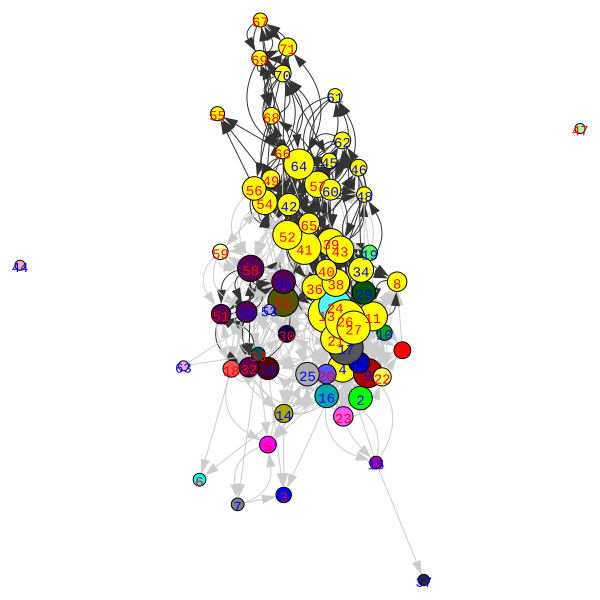

In [ ]:
# ===
# --- Step 4: VISUALIZE NETWORK ---

print("\nPlotting Girvan-Newman Partition:")
ig.plot(
    fgn,
    layout=layout,
    vertex_label=dmg.vs["name"],
    vertex_label_color=vertex_colors,
    vertex_size=scaled_sizes
)



Nodes are sized by in-degree.  This Girvan-Newman partitioning breaks the network into many small groups and one really big group.  In fact, the yellow group in the upper center is one of the few larger clusters, but many others are quite small, even though the nodes are closely connected.  This shows that the algorithm splits the network in a very fine-grained way.


Plotting Walktrap Partition:


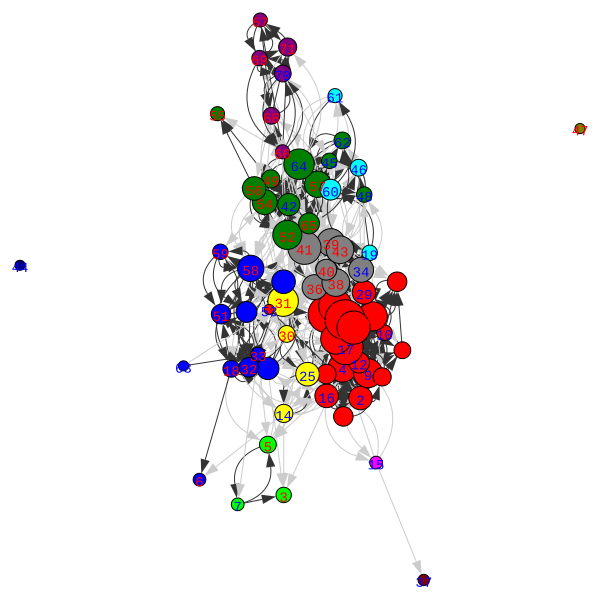

In [ ]:
print("\nPlotting Walktrap Partition:")
ig.plot(
    fwt,
    layout=layout,
    vertex_label=dmg.vs["name"],
    vertex_label_color=vertex_colors,
    vertex_size=scaled_sizes
)



Nodes are sized by in-degree.  This Walktrap partitioning shows the network split into a handful of larger, more cohesive groups.  You can clearly see several large color-coded clusters, such as the red group on the right, the green group in the upper center, and the blue group on the left.  These clusters contain many of the network's most central and well-connected nodes.   People who are linked together tightly are kept together in the same group.

**#5- Tell me anything else about whether the partitioning makes sense, based on attributes or who the nodes are, and so on.**

In [8]:
# ===
# --- Step 5: COMMUNITY VALIDATION BY ATTRIBUTES ---

cb1 = pd.DataFrame({
    'name': dmg.vs['name'],
    'GirvanNewmanMembership': fgn.membership,
    'WalktrapMembership': fwt.membership,
    'PRACTICE': practice_values
})

print("\nFirst few rows of cluster and PRACTICE assignments:")
print(cb1.head())

# --- Column-normalized Crosstabulations ---

print("\nCrosstab (column percentages) of PRACTICE by Girvan-Newman group:")
ct_gn = pd.crosstab(cb1['GirvanNewmanMembership'], cb1['PRACTICE'], normalize='columns') * 100
print(ct_gn.round(1))  # rounded to 1 decimal place

print("\nCrosstab (column percentages) of PRACTICE by Walktrap group:")
ct_wt = pd.crosstab(cb1['WalktrapMembership'], cb1['PRACTICE'], normalize='columns') * 100
print(ct_wt.round(1))



First few rows of cluster and PRACTICE assignments:
  name  GirvanNewmanMembership  WalktrapMembership  PRACTICE
0    1                       0                   0         1
1    2                       1                   0         2
2    3                       2                   1         1
3    4                       3                   0         2
4    5                       4                   1         1

Crosstab (column percentages) of PRACTICE by Girvan-Newman group:
PRACTICE                   1     2
GirvanNewmanMembership            
0                        2.4   0.0
1                        0.0   3.3
2                        2.4   0.0
3                       58.5  36.7
4                        2.4   0.0
5                        2.4   0.0
6                        0.0   3.3
7                        0.0   3.3
8                        0.0   3.3
9                        0.0   3.3
10                       0.0   3.3
11                       0.0   3.3
12                      

This last table shows how the two types of lawyers (litigation and corporate) are spread across the different groups found by the Walktrap algorithm.  Each number shows the percentage of each practice type found in each group.  For example, 26.8% of litigation lawyers are in group 0, while 13.3% of corporate lawyers are in group 5. It helps us see whether people from the same practice area tend to end up in the same groups.  If you run a chi-square test on this table with a total of 71 individuals, the p-value is approximately 0.20.  This means there is no statistically significant relationship between practice-type and Walktrap group membership at common significance levels.